In [2]:
#import the necessary packages 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

C:\Users\nourd\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
from statsmodels.graphics.mosaicplot import mosaic

In [4]:
import statsmodels.formula.api as smf

In [5]:
#remove the warning message 
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

In [6]:
#read the dataset 
development_dataset = pd.read_csv('C:\\Users\\nourd\\Downloads\\archive (6)\\data.csv')

In [7]:
pip install --upgrade pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install --upgrade openpyxl


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
  Attempting uninstall: openpyxl
    Found existing installation: openpyxl 3.1.0
    Uninstalling openpyxl-3.1.0:
      Successfully uninstalled openpyxl-3.1.0


## 1. Descriptive Analysis 

In [9]:
development_dataset.head(10)

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment
0,Denmark,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94
1,Sweden,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74
2,Norway,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37
3,Finland,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99
4,Switzerland,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60
5,Netherlands,82.32,91.19,90.08,87.34,74.03,84.11,79.09,80.82,74.34,95.86,82.05,86.43,62.49
6,Luxembourg,81.83,96.32,89.20,86.31,66.60,78.91,80.72,80.03,76.93,94.56,81.59,78.79,71.98
7,Iceland,81.02,91.64,88.74,83.30,77.75,79.20,72.86,76.07,69.92,93.82,82.72,85.19,71.01
8,Germany,80.81,87.92,87.70,84.39,65.96,78.87,79.70,80.23,73.96,94.42,81.41,83.45,71.69
9,New Zealand,80.47,85.07,87.56,87.19,79.88,82.58,72.82,74.60,69.88,90.66,79.84,83.89,71.71


In [10]:
# Remove leading/trailing spaces and handle case sensitivity in the 'Country' column
development_dataset['Country'] = development_dataset['Country'].str.strip()

In [11]:
development_dataset[development_dataset['Country'] == 'Iceland']

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment
7,Iceland,81.02,91.64,88.74,83.3,77.75,79.2,72.86,76.07,69.92,93.82,82.72,85.19,71.01


In [12]:
development_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     167 non-null    object 
 1   AveragScore                 167 non-null    float64
 2   SafetySecurity              167 non-null    float64
 3   PersonelFreedom             167 non-null    float64
 4   Governance                  167 non-null    float64
 5   SocialCapital               167 non-null    float64
 6   InvestmentEnvironment       167 non-null    float64
 7   EnterpriseConditions        167 non-null    float64
 8   MarketAccessInfrastructure  167 non-null    float64
 9   EconomicQuality             167 non-null    float64
 10  LivingConditions            167 non-null    float64
 11  Health                      167 non-null    float64
 12  Education                   167 non-null    float64
 13  NaturalEnvironment          167 non

In [13]:
#display the statistics of each variable 
development_dataset.describe()

,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,58.056228,67.242515,56.829401,50.360299,54.468024,53.013653,54.791677,55.019701,51.568683,69.803293,68.624910,58.723772,56.231737
std,13.309964,17.542279,19.914638,17.747092,10.350639,16.743723,12.876166,15.849004,13.427811,19.752677,11.166266,19.679023,9.061262
min,30.400000,16.540000,16.160000,13.090000,23.010000,21.690000,20.500000,24.230000,24.460000,19.210000,31.950000,16.780000,33.670000
25%,47.770000,59.290000,39.650000,37.470000,47.820000,40.765000,45.830000,40.055000,41.295000,55.830000,60.595000,44.355000,50.265000
50%,57.530000,68.930000,57.170000,47.510000,54.390000,51.250000,53.520000,56.590000,50.060000,74.770000,71.380000,61.930000,55.540000
75%,66.860000,80.560000,72.865000,60.965000,60.610000,64.640000,62.760000,69.060000,62.555000,86.975000,77.340000,74.130000,61.940000
max,84.550000,96.320000,94.100000,90.410000,82.560000,84.990000,83.840000,85.750000,80.100000,95.860000,86.890000,91.440000,78.740000


Through the table we can see that **SafetySecurity** , **LivingConditions**,and **Health** have high averages accross the board.This can indicate that most countries achieve high levels in these particular indicators.  

Comparing these three indicators in terms of their statistical indicators, we can see that for Health the average to which 75% of data points fall under is less than the other two with a value of 77.34. We can also see that the spread of the data is lower for Health when comparing the standard deviations. Which can make us hypothesize that the health sector is less susceptible to fluctuations in comparison to other indicators which raises the questions to what extent did we achieve the **democratization of healthcare accross the globe** 

One can also wonder about the reason why these three specific variables exhibit such behavior in contrast to the others in the dataset -> **we can achieve this through comparative analysis cross countries for the different variables.**

Through this table, we can see that the environment has the minimum maximum value which can make up for the dire situation of the environment. One aspect that we can study is the differences between the global north and the south and further the interaction between these two in this aspect. 

**Side Note** : We can enhance the categorization adding another dataset to map each country as first world,second world, third world. 

## 2. Data Cleaning Task : Categorizing countries of the dataset 

In [14]:
import openpyxl
print(openpyxl.__version__)

3.1.5


In [15]:
pip install openpyxl==3.1.0

  Using cached openpyxl-3.1.0-py2.py3-none-any.whl.metadata (2.5 kB)
Using cached openpyxl-3.1.0-py2.py3-none-any.whl (250 kB)
  Attempting uninstall: openpyxl
    Found existing installation: openpyxl 3.1.5
    Uninstalling openpyxl-3.1.5:
      Successfully uninstalled openpyxl-3.1.5
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
#open the excel file containing the countries with the specific classification according to the world bank (1)
countries = pd.read_excel('C:\\Users\\nourd\\Downloads\\archive (6)\\CLASS.xlsx')

In [17]:
countries.head()

,Economy,Code,Region,Income group,Lending category
0,Afghanistan,AFG,South Asia,Low income,IDA
1,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD
2,Algeria,DZA,Middle East & North Africa,Upper middle income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High income,NaN
4,Andorra,AND,Europe & Central Asia,High income,NaN


In [18]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Economy           266 non-null    object
 1   Code              266 non-null    object
 2   Region            218 non-null    object
 3   Income group      217 non-null    object
 4   Lending category  145 non-null    object
dtypes: object(5)
memory usage: 10.6+ KB


In [19]:
#we will remove the lending category 
countries.drop("Lending category",axis= 1) 
#rename the column Economy to Country 
countries = countries.rename(columns = {'Economy':'Country'})
countries.head()

,Country,Code,Region,Income group,Lending category
0,Afghanistan,AFG,South Asia,Low income,IDA
1,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD
2,Algeria,DZA,Middle East & North Africa,Upper middle income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High income,NaN
4,Andorra,AND,Europe & Central Asia,High income,NaN


In [20]:
countries.shape

(267, 5)

In [21]:
# convert both the 'Country' column to string data type to make the regular expression smooth 
countries['Country'] = countries['Country'].astype('str')
development_dataset['Country'] = development_dataset['Country'].astype('str')

What we will do is to see the words in **development_dataset** the that have **the word pattern** in the **countries** dataset.Then replace the value in the latter to the former.  

In [22]:
import re

In [23]:
# Function to update countries based on partial matching
def update_countries(dev_dataset, countries):
    for i, dev_country in dev_dataset['Country'].items():
        for country in countries['Country']:
            if re.search(re.escape(dev_country), country, re.IGNORECASE):
                dev_dataset.at[i, 'Country'] = country
                break

# Apply the function to update the dataset
update_countries(development_dataset, countries)

**Merge and Check the countries that still have a null value in Income Group even after the application of the function**

In [24]:
development_dataset_new = pd.merge(development_dataset,countries,on = 'Country',how ='left')

In [25]:
#check for which categories the Income group is null 
development_dataset_new[development_dataset_new['Income group'].isna()]

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Code,Region,Income group,Lending category
24,Czech Republic,75.08,90.64,82.53,68.72,61.62,74.18,62.88,69.70,72.12,91.64,79.49,80.66,66.74,NaN,NaN,NaN,NaN
28,South Korea,74.07,83.03,73.07,69.14,51.59,75.29,64.62,75.61,74.59,91.47,84.80,87.76,57.82,NaN,NaN,NaN,NaN
34,Slovakia,71.15,87.27,78.60,61.93,61.15,68.66,58.14,67.92,63.32,89.47,76.74,72.75,67.84,NaN,NaN,NaN,NaN
93,Kyrgyzstan,55.75,71.90,51.09,41.34,52.43,46.87,46.08,46.98,49.00,74.77,72.46,61.57,54.46,NaN,NaN,NaN,NaN
94,Turkey,55.50,45.70,30.22,36.89,45.02,56.61,56.71,66.38,53.04,80.96,74.19,64.77,55.47,NaN,NaN,NaN,NaN
114,Laos,50.18,75.55,27.51,39.40,45.50,34.58,50.25,53.74,46.61,57.21,66.38,48.89,56.59,NaN,NaN,NaN,NaN
119,Côte d'Ivoire,48.59,60.65,55.05,43.91,43.17,42.37,49.81,42.29,47.48,54.32,51.81,37.15,55.10,NaN,NaN,NaN,NaN
133,Swaziland,45.36,62.03,30.56,36.05,41.87,44.89,46.25,43.16,44.79,55.76,48.43,44.52,46.07,NaN,NaN,NaN,NaN
144,"Venezuela, RB",43.60,40.45,36.63,13.09,58.30,21.69,20.50,43.34,26.44,69.82,69.61,61.10,62.22,VEN,Latin America & Caribbean,NaN,IBRD
160,Democratic Republic of Congo,35.74,31.79,43.55,25.50,40.78,22.54,35.28,28.31,32.45,30.65,50.90,33.61,53.50,NaN,NaN,NaN,NaN


In [26]:
development_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     167 non-null    object 
 1   AveragScore                 167 non-null    float64
 2   SafetySecurity              167 non-null    float64
 3   PersonelFreedom             167 non-null    float64
 4   Governance                  167 non-null    float64
 5   SocialCapital               167 non-null    float64
 6   InvestmentEnvironment       167 non-null    float64
 7   EnterpriseConditions        167 non-null    float64
 8   MarketAccessInfrastructure  167 non-null    float64
 9   EconomicQuality             167 non-null    float64
 10  LivingConditions            167 non-null    float64
 11  Health                      167 non-null    float64
 12  Education                   167 non-null    float64
 13  NaturalEnvironment          167 non

In [27]:
#we need to convert the names of these countries : 'Czech Republic, South Korea, Slovakia,Kyrgyzstan,Turkey,Laos,Côte d'Ivoire
#Swaziland,Venezuela, RB,Democratic Republic of Congo'
development_dataset.loc[development_dataset['Country'] == 'Czech Republic', 'Country'] = 'Czechia' 
development_dataset.loc[development_dataset['Country'] == 'South Korea', 'Country'] = 'Korea, Rep.' 
development_dataset.loc[development_dataset['Country'] == 'Slovakia', 'Country'] = 'Slovak Republic' 
development_dataset.loc[development_dataset['Country'] == 'Kyrgyzstan', 'Country'] = 'Kyrgyz Republic' 
development_dataset.loc[development_dataset['Country'] == 'Turkey', 'Country'] = 'Türkiye' 
development_dataset.loc[development_dataset['Country'] == 'Laos', 'Country'] = 'Lao PDR'  
development_dataset.loc[development_dataset['Country'] == "Côte d'Ivoire", 'Country'] = "Côte d’Ivoire"
development_dataset.loc[development_dataset['Country'] == "Swaziland", 'Country'] = "Eswatini"
development_dataset.loc[development_dataset['Country'] == "Democratic Republic of Congo", 'Country'] = "Congo, Dem. Rep."

Note that Venezuella **does not have an income group** 

In [28]:
development_dataset_new.head()

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Code,Region,Income group,Lending category
0,Denmark,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94,DNK,Europe & Central Asia,High income,NaN
1,Sweden,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74,SWE,Europe & Central Asia,High income,NaN
2,Norway,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37,NOR,Europe & Central Asia,High income,NaN
3,Finland,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99,FIN,Europe & Central Asia,High income,NaN
4,Switzerland,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60,CHE,Europe & Central Asia,High income,NaN


## 3. Analysis 

### 3.1 General Analysis 

What we want to do is to to see the variations of the different indicators according to regions 

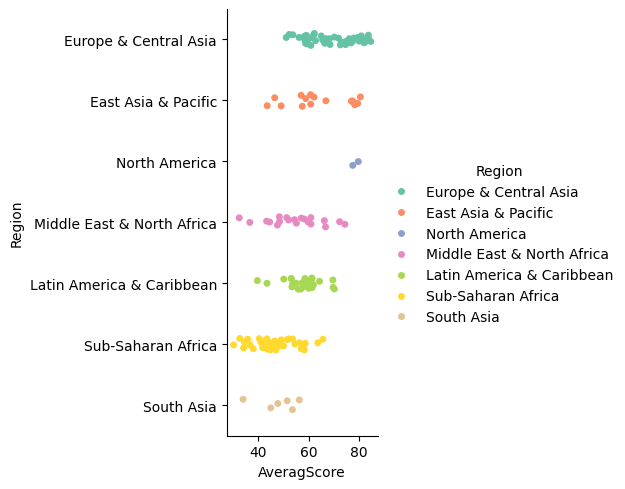

In [29]:
sns.catplot(data=development_dataset_new, x="AveragScore", y="Region",hue = "Region", palette="Set2")

Through the analysis of this graph, we can see the Europe and Central Asia have a condensed values that ranges from 50 to 80 with less variation , for **East Asia and Pacific and Lating America & Caribbean** we see a more sparse distribution where there are high values and below average ones. For **MENA** the same observation pertains although there are more countries with very low Average Score. For **Sub-Saharan Africa and South Asia** the values are all less than 60 percent in average. 

This can indicate that **East Asia and Pacific and Lating America & Caribbean** are in a transition state into development, this can be said to some extent for the **MENA region**. Moreover, development needs to take traction in **Sub-Saharan Africa and South Asia.**

**Reminder on the South Asian Countries** : 1. India // 2. Pakistan // 3. Bangladesh // 4. Sri Lanka // 5. Nepal // 6. Bhutan
7. Maldives // 8. Afghanistan

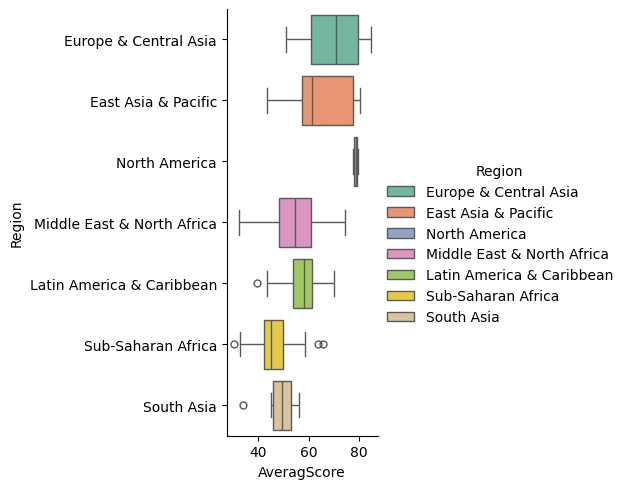

In [30]:
sns.catplot(data=development_dataset_new, x="AveragScore", y="Region", kind="box",hue = "Region", palette="Set2")

- In the previous graph we saw some similarities between the regions: East Asia and Pacific & Latin America, however following the boxplot we can see that the former has more data condensed above the approximately same median value of 60. 
- Moreover, the distribution in Latin America is more symmetrical which indicated that it has a normal distribution where the spread of data is relatively uniform across the data points. The same conclusion applies for almost all regions exept **East Asia and Pacific**. 

In [31]:
development_dataset_new['Income group'].value_counts()

Income group
High income            51
Upper middle income    44
Lower middle income    37
Low income             25
Name: count, dtype: int64

**What can explain the disparity in the East Asia and Pacific Region**

### 3.2 Analysis of the Region East Asia and Pacific Region

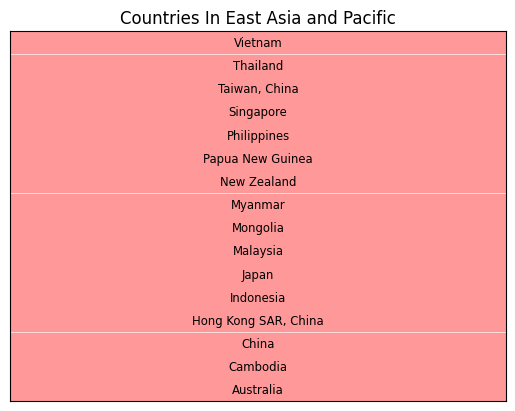

In [32]:
# plot the countries present in the region 
#filter out the dataframe 
development_dataset_east_asia = development_dataset_new[development_dataset_new['Region'] == 'East Asia & Pacific']

# Create a dictionary of counts based on the categories
counts = development_dataset_east_asia.groupby(['Region', 'Country']).size()

# Function to show only the country name
def country_labelizer(key):
    return key[1]  # Extract the country name from the key (Continent, Country)

# Define a uniform color for all tiles
props = lambda key: {'color': '#ff9999'}

# Plot Mosaic
mosaic(counts, title='Countries In East Asia and Pacific',axes_label = False,labelizer = country_labelizer,properties= props)
plt.show()

**Explore the scores in the different countries**

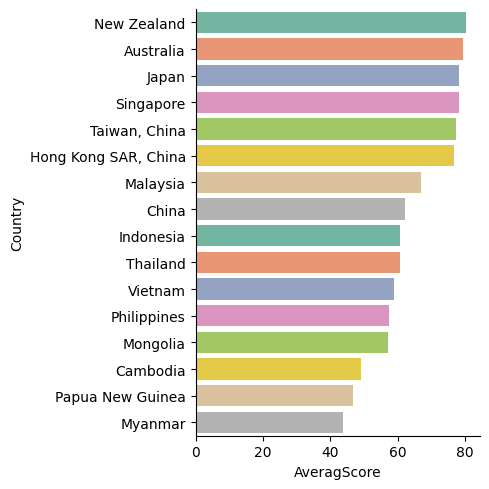

In [33]:
#average score per countries in east asia  
sns.catplot(data=development_dataset_east_asia, x="AveragScore", y="Country",kind = 'bar',hue = "Country",palette = "Set2")

As we can see through the graph that western countries in the region (New Zealand and Australia) have the pinnacle of the average score. Followed by almost as high proportion the Asian Countries that had been been subject to the **Asian Miracle** in the 90s. The lowest proportions are occupied by **Myanmar,Papua New Guinea,and Cambodia.** 

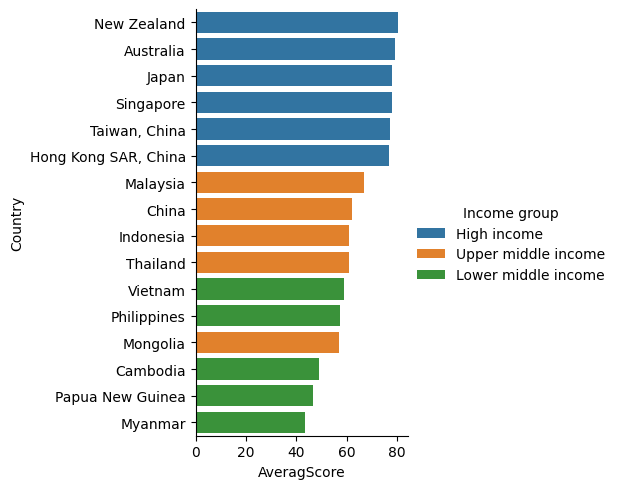

In [34]:
#countries in east asia according to their income group 
sns.catplot(data=development_dataset_east_asia, x="AveragScore", y="Country",kind = 'bar',hue = "Income group")

**This Classification can help us in differentiating between countries in the analysis of their averages**. Through this graph, we can ask why even though Mongolia is upper middle income is still lagging behind vietnam and philippines or in the other perspective are these countries heading towards a higher category. 

<div style= "background-color: lightblue; padding: 10px; border-radius: 5px; font-size: 13px;"> 
   
<b> How Income Classification is done? :</b> 
    
<b> What is the World Bank Atlas method?</b> 
 
The World Bank's official estimates of the size of economies and country classifications by income level are based on Gross National Income (GNI) per capita. For cross-national comparisons, estimates are converted from local currency units (LCU) to current U.S. dollars using the Atlas method, referring to a former World Bank publication called the Atlas of Global Development. The Atlas method smooths exchange rate fluctuations using a three-year moving average, price-adjusted conversion factor. The USD estimate of GNI per capita is derived by applying the Atlas conversion factor to estimates measured in LCU. For more details, see the detailed methodology page.

</div>

What we can explore following this graph is **the difference in the scores in these countries.**

In [35]:
development_dataset_east_asia.columns

Index(['Country', 'AveragScore', 'SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment', 'Code',
       'Region', 'Income group', 'Lending category'],
      dtype='object')

In [36]:
concerned_cols = ['Country', 'SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment']
#filter out the dataframe only to include the cols containing the indicators 
development_dataset_east_asia_filtered = development_dataset_east_asia[concerned_cols] 

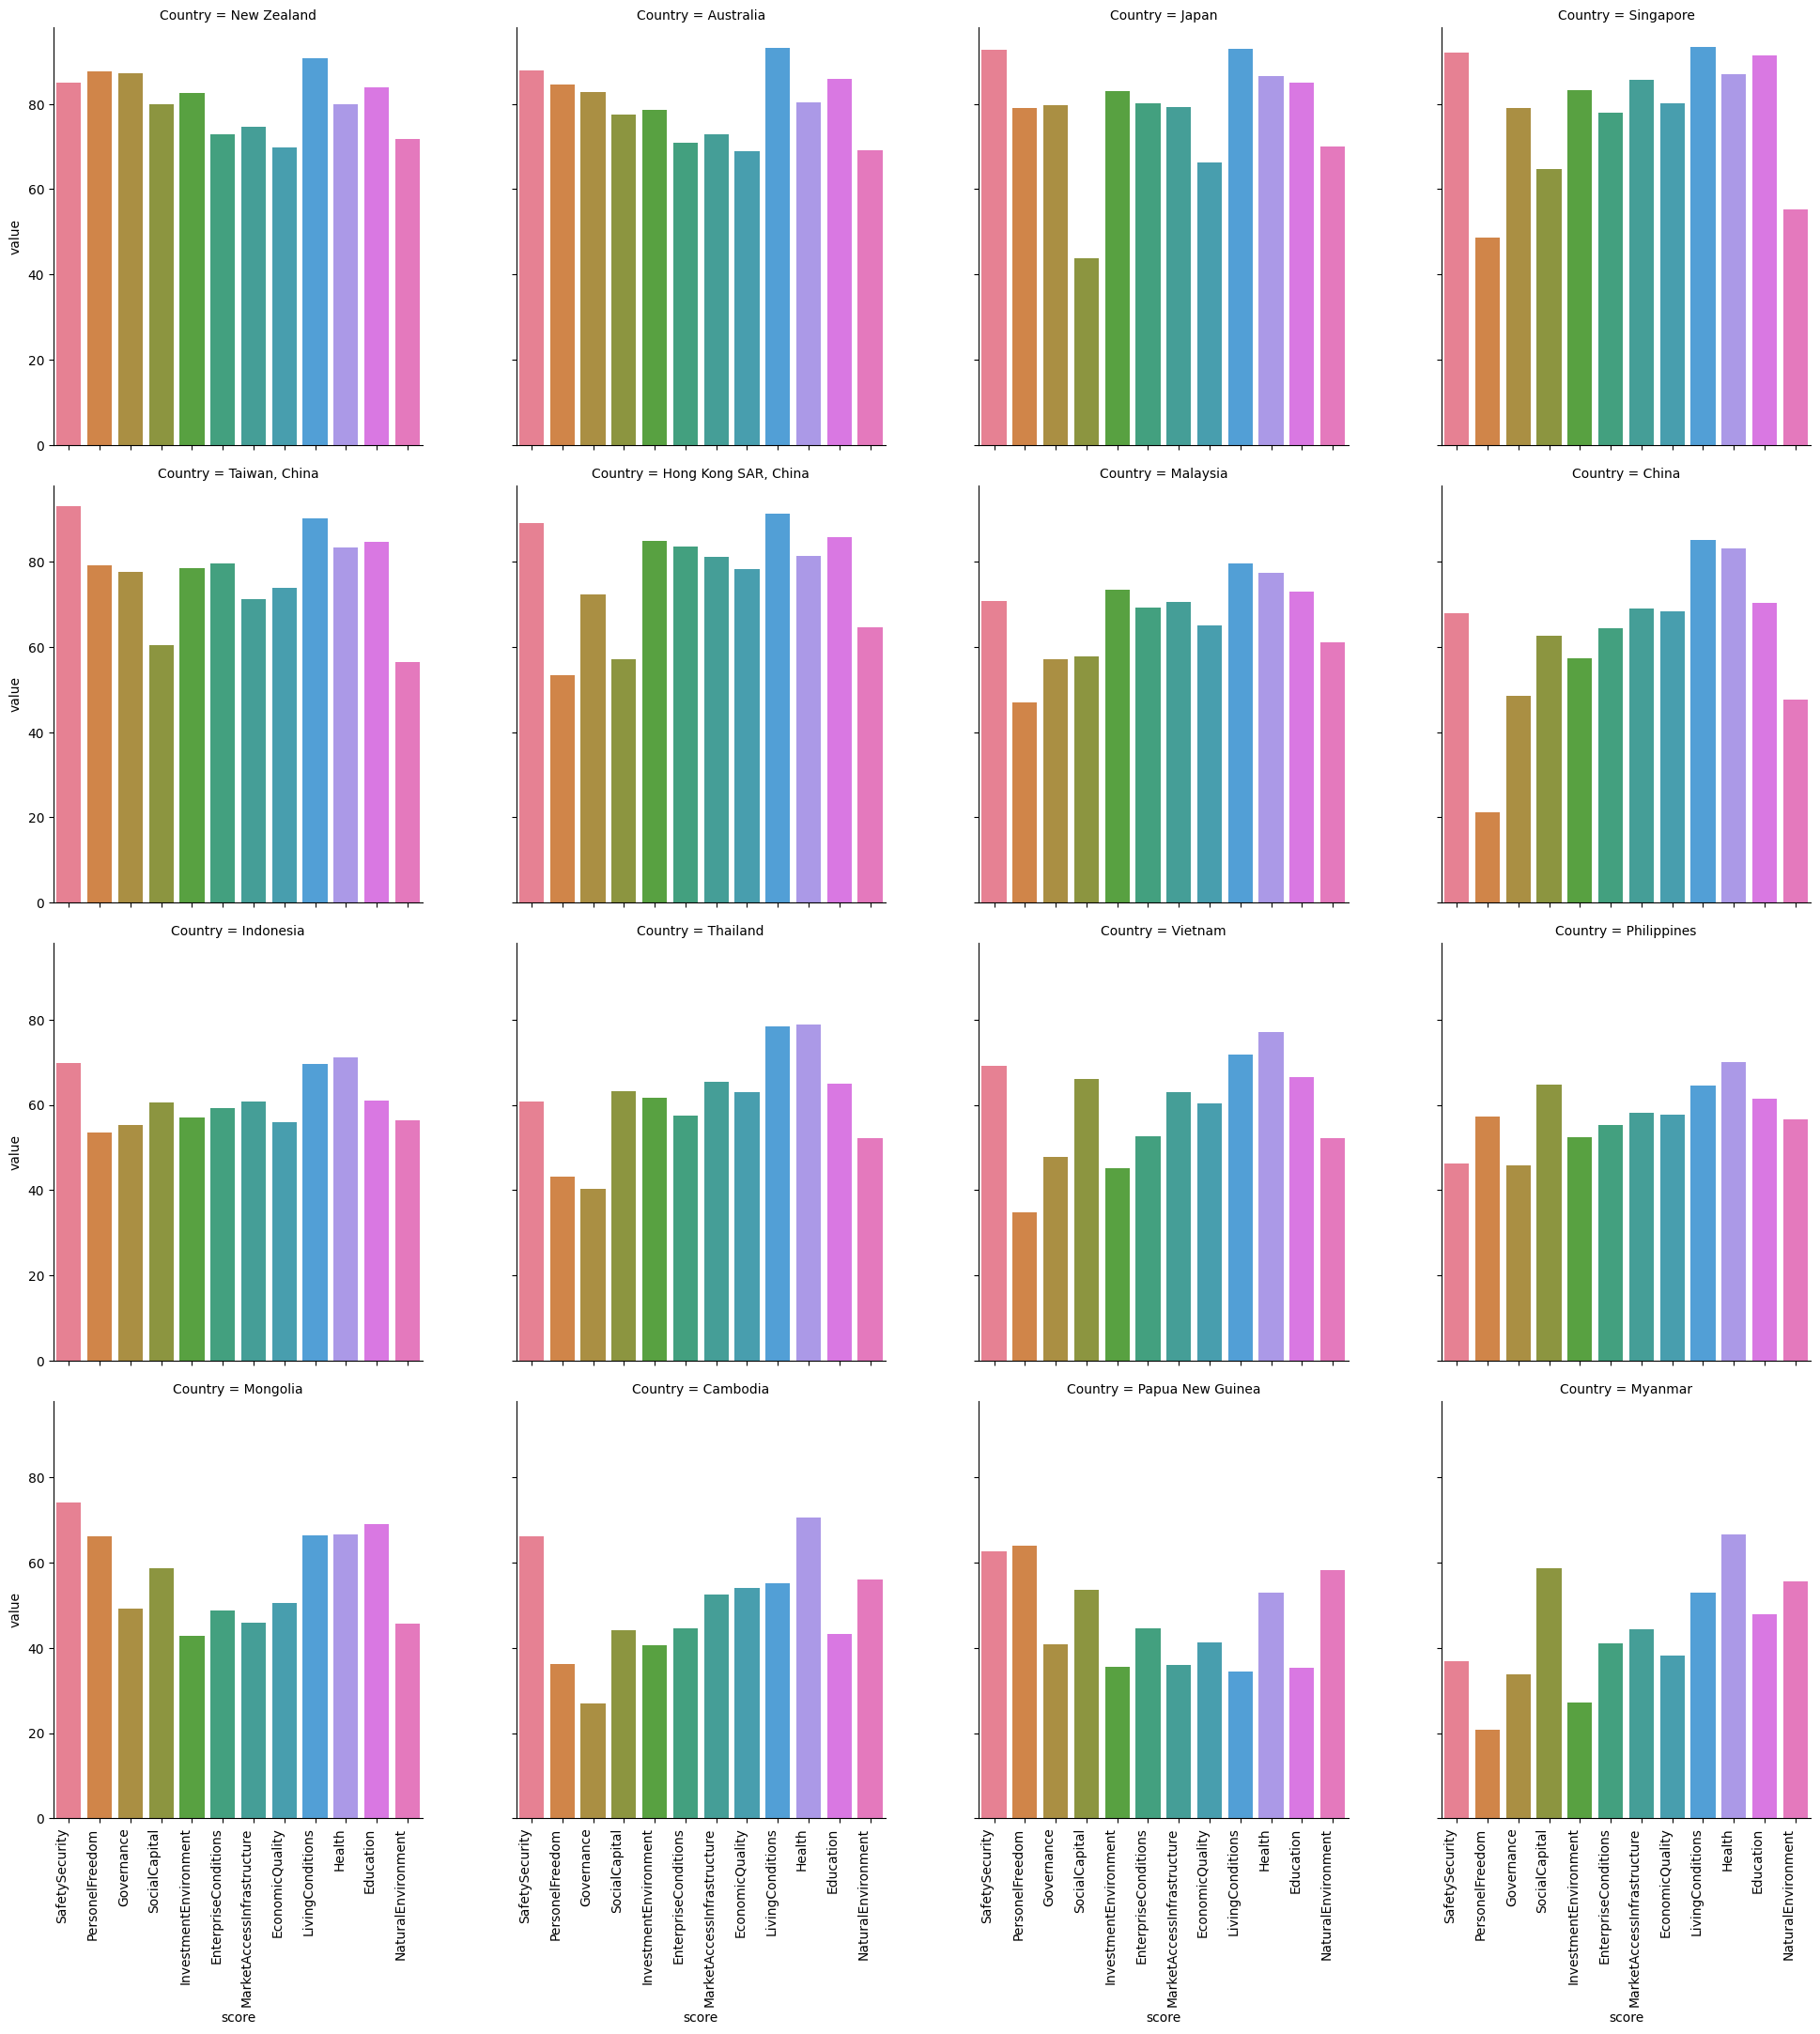

In [37]:
#we will reshape for data visualization purposes 
east_asia_reshaped = pd.melt(development_dataset_east_asia_filtered,id_vars = 'Country')  
#rename the columns 
east_asia_reshaped.rename(columns = {'variable':'score'},inplace = True)
#plot the data 
g = sns.catplot(kind='bar', data=east_asia_reshaped, x='score', y='value',hue = 'score', col='Country',col_wrap = 4)

# Rotate x-axis text for all subplots
for ax in g.axes.flatten():
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right') 


# Show the plot
plt.show()


Through the graph, we can see that the indicators Security, Living Conditions,Health,Education are relatively higher than other factors almost across all countries in the region. Except for **Cambodia,Papua New Guinea,Myanmar** where **Education is lagging behind**. One important aspect to note is the relatively high proportion of Presonal Freedom in comparison to similar countries.

The lower overall average in **Mongolia** can be attribute to a lesser values in **EconomicQuality,MarketAcessibilityInfrastucture,EnterpriseConditions,and InvestmentEnvironment.** 
-> We can put forward the hypothesis that this might be due to the current majority that the **Mongolian People's Party (MPP)** has in the Mongolian Parliament.

*Idea to explore further* : 
We can see the difference in indicators accross communist vs non communist // **The Current Communist countries : China (PRC)
Cuba / Laos / Korea (DPRK) / Vietnam**

**Note that there is no data from North Korea in the original dataset**

### 3.3 Indicators in terms of Countries with Communism as political and economic system.

In [38]:
communist_countries = ['Cuba','China','Laos','Vietnam']

In [39]:
development_dataset_communist = development_dataset_new[development_dataset_new['Country'].isin(communist_countries)]

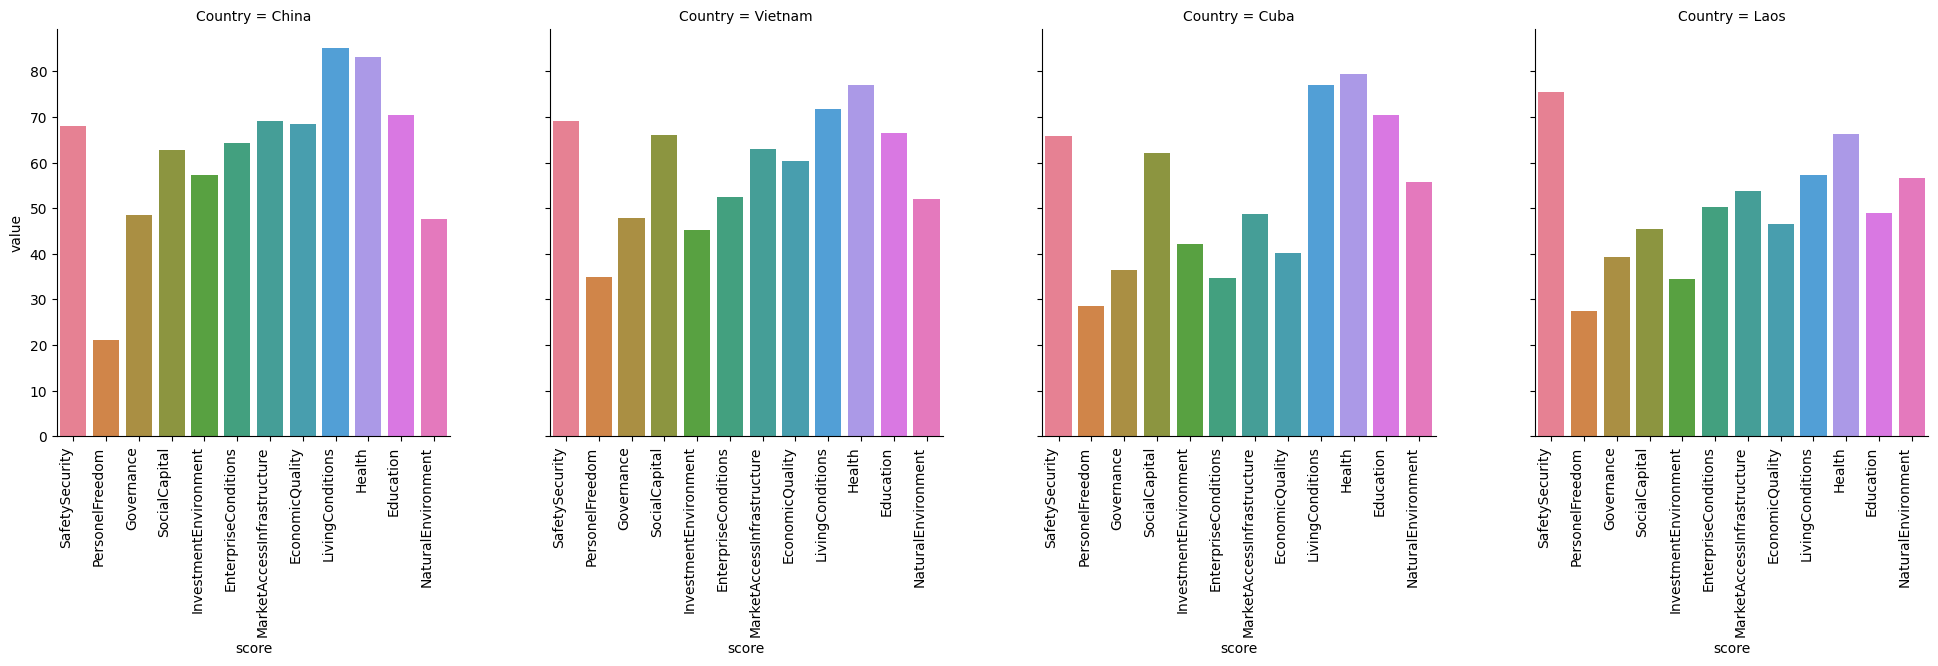

In [40]:
#plot the different indicators 

#remove unnecessary columns 
development_dataset_communist = development_dataset_communist[concerned_cols]

#we will reshape for data visualization purposes 
communism_reshaped = pd.melt(development_dataset_communist,id_vars = 'Country')  


#rename the columns 
communism_reshaped.rename(columns = {'variable':'score'},inplace = True)
#plot the data 
g = sns.catplot(kind='bar', data=communism_reshaped, x='score', y='value',hue = 'score', col='Country',col_wrap = 4)

# Rotate x-axis text for all subplots
for ax in g.axes.flatten():
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right') 


# Show the plot
plt.show()

Accross all communist countries,there is a **low degree in PersonalFreedom** . The economic factors have good proportions in China and Vietnam in contrast to Cuba and Laos. **Although Cuba is distinguished from Laos by its high LivingConditions,Health,Education.**

### 3.4 Environmental Indicator Analysis 

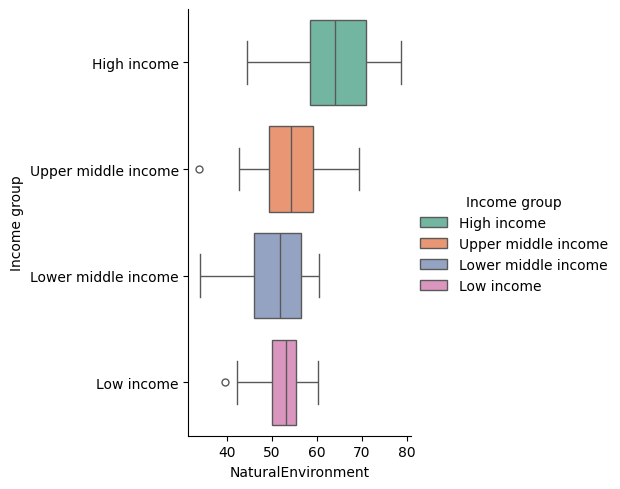

In [41]:
sns.catplot(data=development_dataset_new, x='NaturalEnvironment', y='Income group',hue = 'Income group', palette="Set2",kind='box')

The environmental protection gets lower in relation to the income group of the country with equal median amounts for **lower middle income countries and low income.** This is regrettable as nation who is not in the first world are the most prone to e affected by the worsened climate conditions but we have to take into consideration that the primary needs of the nation are not met so it leads to **deprioritize the sustainability agenda.**

A key aspect that we need to take into consideration is the fact that countries belonging to High income level mostly emit higher levels of pollutants thus the environmental care must be sustantial, but the general question one ought to ask is: are these enough or the technological advances are deemed to grow exponentially in a way that will diminish the environment in no way that our actions can rectify or there are redeemable aspects that can make us live in harmony with technology and nature 

However Shafik (1994) argues in her paper titled **'Economic Development and Environmental Quality : An Econometric Analysis'** that the classification of poor vs rich does not help in explaining environmental disparity citing the example presented by (Davis 1992) where tribal people use conservation so the difference lies primarily in budget constraints. 

-> But this is not in concordance with the data we have in the dataset, which might suggest that new updates to the study need to be considered or the author might had fallen in hasty generalizational fallacy. 
Another key idea to consider is the fact that low income countries tend to be industry based. It is believed that in order to achieve development we need to pass from the industrialization stage to a service based economy where it is possible to minimize the environmental cost. This idea is particularly is described in **Rostow's stages of growth** which has been heavily critized. 

The environmental quality has multiple indicators that inform its progress these include but not limited to **the lack of clean water**, **lack of urban sanitation**, **ambient levels of suspended particulate matter (SPM)**, **ambient sulfur oxides (S02)' change in forest area between 1961-86**, **the annual rate of deforestation between 1962-86**, **dissolved oxygen in rivers**, **fecal coliforms in rivers**, **municipal waste per capita, and carbon emissions per capita."** Six of these indicators (water, sanitation, SPM,S02, dissolved oxygen, and fecal coliforms in rivers) appropriately measure the quality of a stock of natural resources.  

These indicators react differently according to the paper to economic growth, specifically, **water and sanitation improve with rising income**, **some worsen then improve like particulates and sulfur oxides**, and **others worsen steadily like dissolved oxygen in rivers,municipal solid wastes, and carbon emissions.**

-> This can indicate that the relationship between these two is not linear, so the large values in high income countries and lesser to an extent in other countries is ambiguous. 

What I want to inspect is the **relationship between governance and personal freedom.** Are countries who are well governed tend to have the democratic value of personal freedom intact, or not necessacrily and how is it a contributor to development. 

In [42]:
development_dataset_new.columns

Index(['Country', 'AveragScore', 'SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment', 'Code',
       'Region', 'Income group', 'Lending category'],
      dtype='object')

In [43]:
#scatter plot that depects governance vs personal freedom 
X = development_dataset_new[['Governance','PersonelFreedom']]

In [44]:
development_dataset_new.head()

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Code,Region,Income group,Lending category
0,Denmark,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94,DNK,Europe & Central Asia,High income,NaN
1,Sweden,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74,SWE,Europe & Central Asia,High income,NaN
2,Norway,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37,NOR,Europe & Central Asia,High income,NaN
3,Finland,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99,FIN,Europe & Central Asia,High income,NaN
4,Switzerland,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60,CHE,Europe & Central Asia,High income,NaN


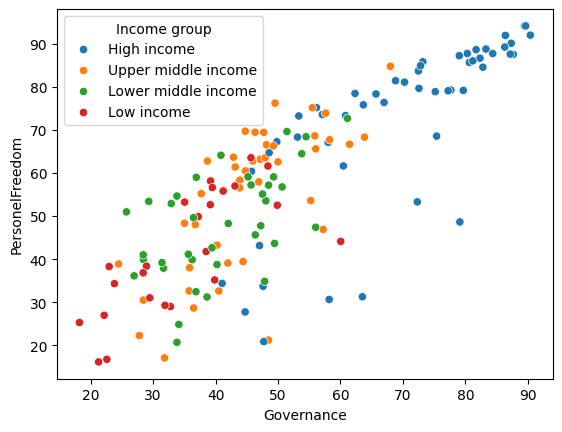

In [45]:
#Visualise data points
sns.scatterplot(x = 'Governance', y = 'PersonelFreedom' , data = development_dataset_new,hue = 'Income group')
plt.xlabel('Governance')
plt.ylabel('PersonelFreedom')
plt.show()

The two variables generally have an increasing linear relationship. We can see that for high income countries whenever the governance is high there is a high level of personal freedom. However it is important to mention that there are with medium levels of the two in these indicators. **It would be a good medlling in we used fixed effects models where each income group gets its own intercept and line to see the differences.** 

In [46]:
development_dataset_new.rename(columns={'Income group': 'Income_group'}, inplace=True)

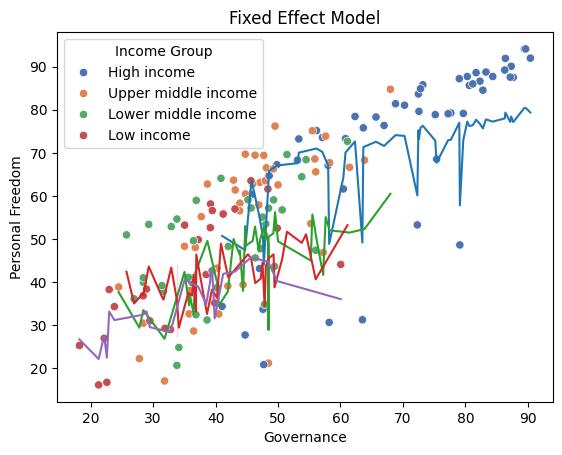

In [47]:
# Fit the fixed effects model
fe = smf.ols("Governance ~ PersonelFreedom + C(Income_group)", data=development_dataset_new).fit()
fe_dev = development_dataset_new.assign(y_hat=fe.fittedvalues)

# Scatter plot using Seaborn, with "Income_group" as the hue
sns.scatterplot(data=development_dataset_new, x="Governance", y="PersonelFreedom", hue="Income_group", palette="deep")

# Add lines for each Income group
for income_group in fe_dev["Income_group"].unique():
    plot_df = fe_dev.query(f"Income_group =='{income_group}'")
    sns.lineplot(data=plot_df, x="Governance", y="y_hat")

# Add title and show the plot
plt.title("Fixed Effect Model")
plt.xlabel("Governance")
plt.ylabel("Personal Freedom")
plt.legend(title='Income Group')
plt.show()

**Fit each data into a line** 

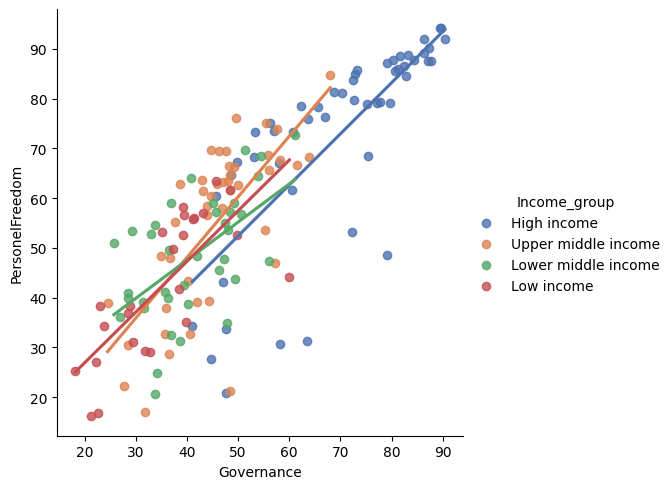

In [48]:
# Use lmplot to fit a linear model for each Income group and plot it
sns.lmplot(x="Governance", y="PersonelFreedom", data=development_dataset_new, hue="Income_group", palette="deep", scatter=True, ci=None)

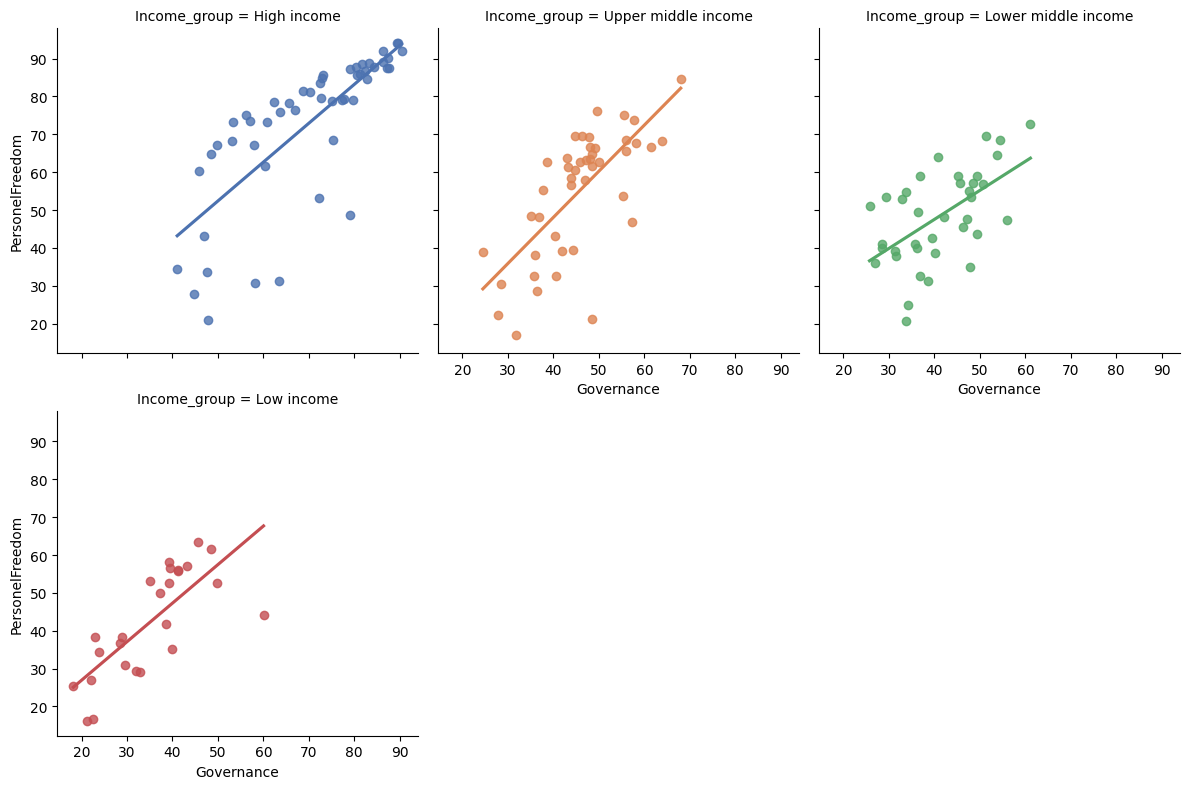

In [49]:
# I will do the chart again but each income group has its own chart 
sns.lmplot(x="Governance", y="PersonelFreedom", 
           data=development_dataset_new, 
           hue="Income_group", 
           palette="deep", 
           scatter=True, 
           ci=None, 
           col="Income_group",  # Separate plots by Income_group
           col_wrap=3,  # Arrange charts in a grid (optional, use 3 charts per row)
           height=4,  # Set the height of each subplot
           aspect=1)  # Set the aspect ratio of each subplot
plt.show()


Plotting each income group individually, we can see that lower middle income has higher variance around the fitting line than other income groups. 

**Statistical Modelling of the Linear regression** 

In [50]:
import statsmodels.formula.api as smf

# Loop through each unique income group
for income_group in development_dataset_new["Income_group"].dropna().unique():
    # Filter the data for the specific income group
    subset = development_dataset_new[development_dataset_new["Income_group"] == income_group]
    
    # Fit a linear regression model using statsmodels
    model = smf.ols("PersonelFreedom ~ Governance", data=subset).fit()
    
    # Print the summary of the linear regression model for the specific income group
    print(f"Income Group: {income_group}")
    print(model.summary())
    print("\n" + "-"*80 + "\n")

Income Group: High income
                            OLS Regression Results                            
Dep. Variable:        PersonelFreedom   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     66.12
Date:                Fri, 01 Nov 2024   Prob (F-statistic):           1.20e-10
Time:                        09:28:56   Log-Likelihood:                -201.36
No. Observations:                  51   AIC:                             406.7
Df Residuals:                      49   BIC:                             410.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0553     

For all of the income the increase in goverenance by one unit results in a unit increase of personal freedom except for **lower middle income countries where personal freedom increases by only 0.76.**

As we have noted in the linear representation of the income group,we can see in the statistical summary that it indeed has the lowest R squared meaning that that governance explains only 35% of the changes in personal freedom. 

This insinuates that this category has a fuziness to it in comparison to other income groups. 

### Exploring the Lower Middle Income Countries 

In [51]:
lower_income = development_dataset_new[development_dataset_new['Income_group'] == 'Lower middle income']

In [52]:
lower_income.columns

Index(['Country', 'AveragScore', 'SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment', 'Code',
       'Region', 'Income_group', 'Lending category'],
      dtype='object')

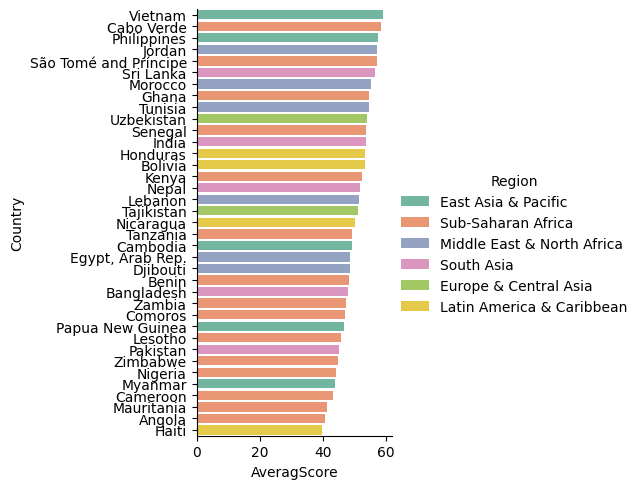

In [53]:
sns.catplot(y='Country', x='AveragScore', data=lower_income, hue='Region', kind='bar', palette='Set2', orient='h')

# Show the plot
plt.show()

The majority of the countries depicted are from Sub-Saharan Africa.

These are the countries that are in transition period where there is improvement in governance but it did not touch yet the personal freedom. But here it a reminder of specific countries that have high scores expect for personal freedom, which makes me want to explore **the role of religion in personal freedom.** 

In [54]:
development_dataset_new.head()

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Code,Region,Income_group,Lending category
0,Denmark,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94,DNK,Europe & Central Asia,High income,NaN
1,Sweden,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74,SWE,Europe & Central Asia,High income,NaN
2,Norway,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37,NOR,Europe & Central Asia,High income,NaN
3,Finland,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99,FIN,Europe & Central Asia,High income,NaN
4,Switzerland,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60,CHE,Europe & Central Asia,High income,NaN


The classification distinguishes between **closed autocracies (score 0)**, **electoral autocracies (score 1)**, **electoral democracies (score 2)**, and **liberal democracies (score 3)**.

**Explanations of the Type of governments**  
1. **Closed autocracy**: citizens do not have the right to choose either the chief executive of the government or the legislature through multi-party elections
2. **Electoral autocracy**: citizens have the right to choose the chief executive and the legislature through multi-party elections; but they lack some freedoms, such as the freedoms of association or expression that make the elections meaningful, free, and fair 
3. **Electoral democracy**: citizens have the right to choose the chief executive and the legislature in meaningful, free and fair, and multi-party elections
4. **Liberal democracy**: electoral democracy and citizens enjoy individual and minority rights, are equal before the law, and the actions of the executive are constrained by the legislative and the courts

In [55]:
#load the dataset for political regime 
political_regime = pd.read_excel('C:\\Users\\nourd\\OneDrive\\Documents\\political-regime-2023.xlsx')

In [56]:
#drop the year column 
political_regime.drop(columns={'Year'},inplace = True)

In [57]:
#rename Entity in the dataset as Country
political_regime.rename(columns = {'Entity' : 'Country'},inplace = True)

In [58]:
development_dataset_new.columns

Index(['Country', 'AveragScore', 'SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment', 'Code',
       'Region', 'Income_group', 'Lending category'],
      dtype='object')

**Needs further ramifications**

In [59]:
#remove the country column in the political regime to get only one country column after melting the two datasets 
political_regime.drop(columns = ['Country'],inplace = True)  

In [60]:
#left join the two datasets 
development_dataset_new = pd.merge(development_dataset_new,political_regime,on='Code',how ='left')
development_dataset_new.head()

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Code,Region,Income_group,Lending category,Political regime
0,Denmark,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94,DNK,Europe & Central Asia,High income,NaN,3.0
1,Sweden,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74,SWE,Europe & Central Asia,High income,NaN,3.0
2,Norway,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37,NOR,Europe & Central Asia,High income,NaN,3.0
3,Finland,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99,FIN,Europe & Central Asia,High income,NaN,3.0
4,Switzerland,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60,CHE,Europe & Central Asia,High income,NaN,3.0


In [61]:
development_dataset_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     176 non-null    object 
 1   AveragScore                 176 non-null    float64
 2   SafetySecurity              176 non-null    float64
 3   PersonelFreedom             176 non-null    float64
 4   Governance                  176 non-null    float64
 5   SocialCapital               176 non-null    float64
 6   InvestmentEnvironment       176 non-null    float64
 7   EnterpriseConditions        176 non-null    float64
 8   MarketAccessInfrastructure  176 non-null    float64
 9   EconomicQuality             176 non-null    float64
 10  LivingConditions            176 non-null    float64
 11  Health                      176 non-null    float64
 12  Education                   176 non-null    float64
 13  NaturalEnvironment          176 non

In [62]:
development_dataset_new[development_dataset_new['Political regime'].isna()]

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Code,Region,Income_group,Lending category,Political regime
95,Belize,55.91,67.49,69.68,44.75,49.95,42.54,49.06,52.22,41.64,72.34,70.61,51.09,59.59,BLZ,Latin America & Caribbean,Upper middle income,Blend,NaN


In [63]:
## assign libearl democracy in the political regime of Belize 
development_dataset_new.loc[development_dataset_new['Country'] == 'Belize','Political regime'] = 3

In [64]:
#convert the variable 'Political regime' float to integer  
development_dataset_new['Political regime'] = development_dataset_new['Political regime'].astype(int)

**Plot the average score for lower middle income countries in relation to the political regime**

In [65]:
lower_income = development_dataset_new[development_dataset_new['Income_group'] == 'Lower middle income']

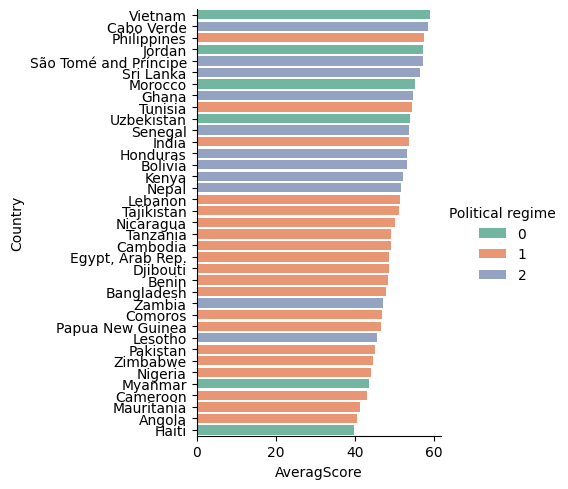

In [66]:
sns.catplot(y='Country', x='AveragScore', data=lower_income, hue='Political regime', kind='bar', palette='Set2', orient='h')

# Show the plot
plt.show()

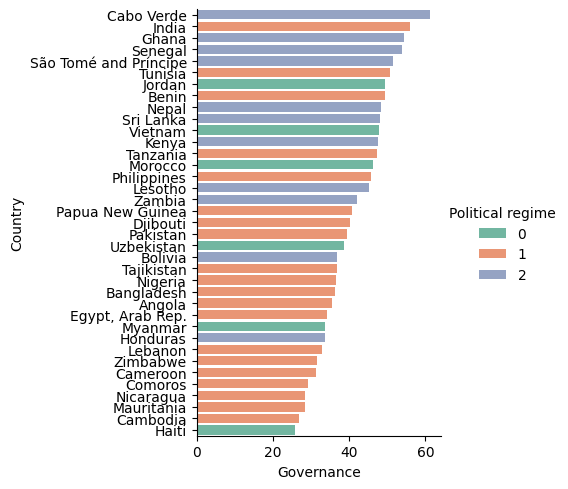

In [67]:
# Sort the data by 'Governance' in descending order
lower_income_sorted = lower_income.sort_values(by='Governance', ascending=False)

# Use the sorted data to determine the order of the 'Country' column
sns.catplot(
    y='Country', 
    x='Governance', 
    data=lower_income, 
    hue='Political regime', 
    kind='bar', 
    palette='Set2', 
    orient='h', 
    order=lower_income_sorted['Country']
)

# Show the plot
plt.show()


Through the chart, we can see that countries with the highest governance rates in this case are the ones with **electorial democracy**, we can also detect the absence of the lieral democracy.  

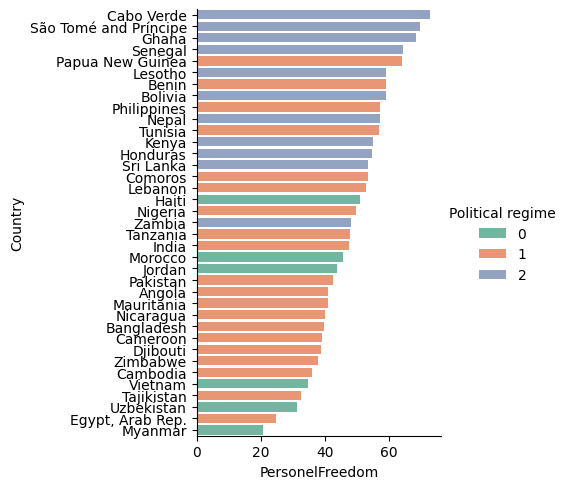

In [68]:
# Sort the data by 'Governance' in descending order
lower_income_sorted = lower_income.sort_values(by='PersonelFreedom', ascending=False)

# Use the sorted data to determine the order of the 'Country' column
sns.catplot(
    y='Country', 
    x='PersonelFreedom', 
    data=lower_income, 
    hue='Political regime', 
    kind='bar', 
    palette='Set2', 
    orient='h', 
    order=lower_income_sorted['Country']
)

# Show the plot
plt.show()

For personal freedom with values higher than 50 there is no closed autocracies with the majority of it electorial democracy and few are electoral democracy. While some countries'governance have an effect on the personal freedom level, it is important to note that for example even though India has a **high governance**, it is very low in **personal freedom aspect.** 

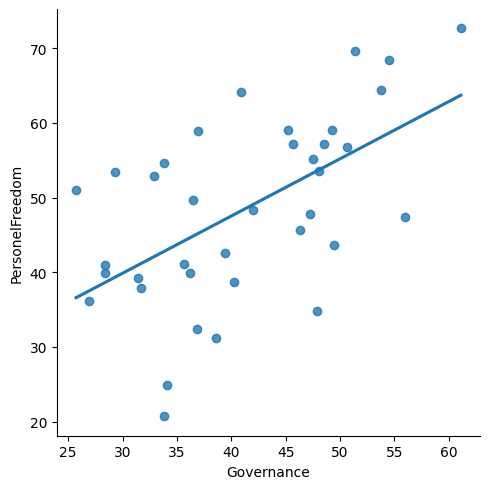

In [69]:
## Governance vs PersonalFreedom for Lower Middle Income Countries 
sns.lmplot(x="Governance", y="PersonelFreedom", data=lower_income, palette="deep", scatter=True, ci=None)

### Studying the relationship between the indicators

In the previous example, we have explored the intuitive relationship between governance and personal freedom, we should acknowledge the possibility of the existence of relationship not so obvious thus the need for this section. 

In [70]:
development_dataset_new.head()

,Country,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Code,Region,Income_group,Lending category,Political regime
0,Denmark,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94,DNK,Europe & Central Asia,High income,NaN,3
1,Sweden,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74,SWE,Europe & Central Asia,High income,NaN,3
2,Norway,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37,NOR,Europe & Central Asia,High income,NaN,3
3,Finland,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99,FIN,Europe & Central Asia,High income,NaN,3
4,Switzerland,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60,CHE,Europe & Central Asia,High income,NaN,3


In [71]:
development_dataset_new.columns

Index(['Country', 'AveragScore', 'SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment', 'Code',
       'Region', 'Income_group', 'Lending category', 'Political regime'],
      dtype='object')

In [72]:
num_variables = ['SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment']

<Axes: >

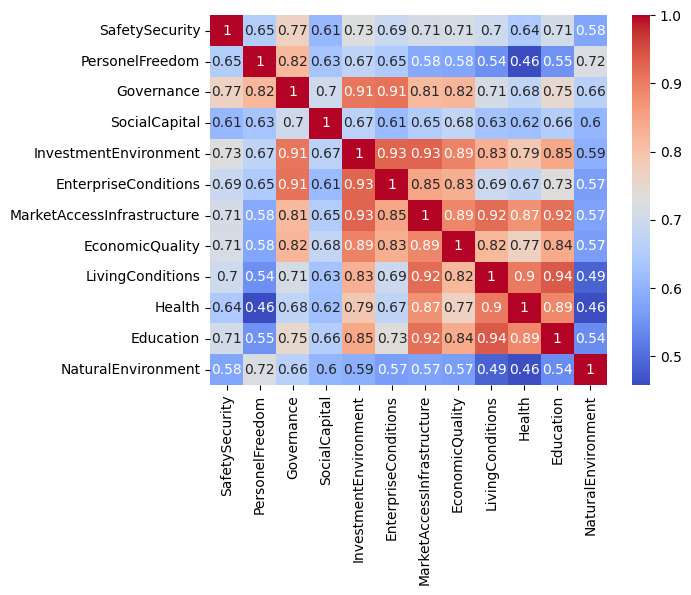

In [73]:
correlations_of_variables = development_dataset_new[num_variables].corr() 
sns.heatmap(correlations_of_variables , annot = True , cmap = 'coolwarm' )

**Governance :**
Aside from personal freedom, the Governance is highly correlated with **InvestmentEnvironment** and **Enterprise Conditions** which can be explained by the strong and interdependent between politics and economics. In a lesser amount but sturdy relationship nevertheless, MarketAccessInfrastructure and Economic Quality which can be contributed to the aforementioned reason, although we might be interested to know **why there first two have a stronger relationship with Governance**. 
It is important to mention that there is a correlation as well between governance with both education and safety security. 

**InvestmentEnvironment** : have a strong correlation with the indicators that pertain to the economic condition of the country as well as education and health.

The same observation is consistent with the **EnterpriseConditions,MarketAccessInfrastucture,Economic Quality,Living Conditions,Health,and Education.**

The only indication where **NaturalEnvironment** has the highest correlation with is **PersonalFreedom** 

-> Through the previous analysis, we can see that almost all indicators have a strong correlation with the economic indicators through this we can make the hypothesis that these specific factors can enaabler of propsoerity and the development of the country. **The expection to this is social capital.**

In a paper **Carlsson, F., & Lundström, S. (2001)** that has the objective of studying the relationship between freedom and CO2 emissions, it had been proved that the emissions increases with the GDP level but decreases in terms of the political freedom. This also has been attested for other types of pollutants.  

It is also important to denote the importance of Health and Education has factors that need to be established in a country in order to expedite devlopment. 

## 4. PCA and Clustering

### 4.1. Exploring Clustering 

Clustering using the income type

In [74]:
development_dataset_new.columns

Index(['Country', 'AveragScore', 'SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment', 'Code',
       'Region', 'Income_group', 'Lending category', 'Political regime'],
      dtype='object')

In [77]:
#filter out the dataframe to include only relevant columns 

development_dataset_cluster = development_dataset_new[['SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment',
        'Income_group']]

development_dataset_cluster.head()

,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Income_group
0,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94,High income
1,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74,High income
2,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37,High income
3,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99,High income
4,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60,High income


### Feature Scaling 

In our case we will just transform all the data points in the dataset by dividing by 100 

In [78]:
num_cols = ['SafetySecurity', 'PersonelFreedom',
       'Governance', 'SocialCapital', 'InvestmentEnvironment',
       'EnterpriseConditions', 'MarketAccessInfrastructure', 'EconomicQuality',
       'LivingConditions', 'Health', 'Education', 'NaturalEnvironment']
development_dataset_cluster[num_cols] = development_dataset_cluster[num_cols] / 100

### K-means Clustering

In [80]:
#declare the feature vector and the target variable 

X = development_dataset_cluster.drop(columns=['Income_group']) 

y = development_dataset_cluster['Income_group']


In [82]:
#convert catgeorical variables into integers 

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

development_dataset_cluster['Income_group'] = le.fit_transform(development_dataset_cluster['Income_group'])

y = le.transform(y)


We will try to model for 4 different clusters operating under the assumption that the groups of income are distinctively different

In [83]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=0) 

kmeans.fit(X)

KMeans(n_clusters=4, random_state=0)

In [84]:
kmeans.cluster_centers_

array([[0.67482113, 0.52454789, 0.46879296, 0.54363239, 0.53258451,
        0.53512958, 0.57798451, 0.51798592, 0.75723521, 0.7214831 ,
        0.63367324, 0.53717887],
       [0.6202619 , 0.48389762, 0.39856429, 0.48543095, 0.39430952,
        0.47023333, 0.39601429, 0.41039762, 0.48716429, 0.56751429,
        0.37871667, 0.52486667],
       [0.86567727, 0.81131364, 0.75184773, 0.64449091, 0.75321364,
        0.70765   , 0.74514545, 0.68658409, 0.91714318, 0.79989773,
        0.81940682, 0.66930909],
       [0.33302632, 0.33486842, 0.27501053, 0.42364737, 0.29877895,
        0.38535263, 0.33515263, 0.35422632, 0.43447895, 0.54732632,
        0.33866842, 0.49522105]])

In [85]:
kmeans.inertia_

13.889790915989998

### Check quality of the classification of the model 

In [86]:
labels = kmeans.labels_

# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

Result: 29 out of 176 samples were correctly labeled.


In [87]:
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Accuracy score: 0.16


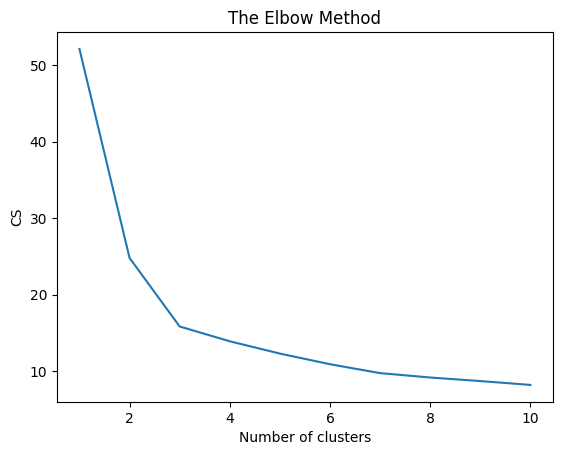

In [88]:
### The elbow method to find the optimal number of clusters 

from sklearn.cluster import KMeans
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

Acccording to the elbow method the optimal number of cluster in the dataset is 3, we can now test its accuracy as above. 

In [89]:
kmeans1 = KMeans(n_clusters=6, random_state=0)

kmeans1.fit(X)

labels1 = kmeans1.labels_

# Check how many of the samples were correctly labeled
correct_labels1 = sum(y == labels1)

print("The value of inertia: {0:0.2f}".format(kmeans1.inertia_))
print("Result: %d out of %d samples were correctly labeled." % (correct_labels1, y.size))
print("Accuracy score: {0:0.2f}".format(correct_labels1 / float(y.size)))


The value of inertia: 10.89
Result: 19 out of 176 samples were correctly labeled.
Accuracy score: 0.11


When experimenting with different cluster values, we can see that 6 clusters succeed in depecting lower value of inertia at the same time the highest value of accuracy score. 

The absence of good results in the K-means clustering might be attributed to the high number of features. -> **so the solution is to take two features that we want to study their relationship in terms of the income groups.**

-> **This can be solved through the elaboration of PCA analysis**

### 4.2. PCA Analysis

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
import numpy as np 

In [91]:
# set the country column as index to the dataframe 
development_dataset_new.set_index('Country',inplace = True)

In [92]:
development_dataset_new.head()

,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,Code,Region,Income_group,Lending category,Political regime
Country,,,,,,,,,,,,,,,,,,
Denmark,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94,DNK,Europe & Central Asia,High income,NaN,3
Sweden,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74,SWE,Europe & Central Asia,High income,NaN,3
Norway,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37,NOR,Europe & Central Asia,High income,NaN,3
Finland,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99,FIN,Europe & Central Asia,High income,NaN,3
Switzerland,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60,CHE,Europe & Central Asia,High income,NaN,3


In [93]:
# fix the X variable containing the indicators 
X = development_dataset_new.iloc[: , 0:13]

In [94]:
# Split the dataset into training and test sets
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

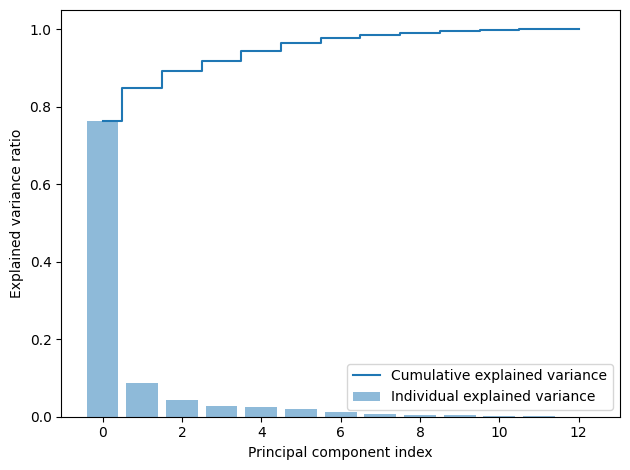

In [95]:
# Scale the dataset; This is very important before you apply PCA
#
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)
#
# Instantiate PCA
#
pca = PCA()
#
# Determine transformed features
#
X_train_pca = pca.fit_transform(X_train_std)
#
# Determine explained variance using explained_variance_ration_ attribute
#
exp_var_pca = pca.explained_variance_ratio_
#
# Cumulative sum of eigenvalues; This will be used to create step plot
# for visualizing the variance explained by each principal component.
#
cum_sum_eigenvalues = np.cumsum(exp_var_pca)
#
# Create the visualization plot
#
plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [96]:
print(exp_var_pca)

[7.63162712e-01 8.64104644e-02 4.19042576e-02 2.73288430e-02
 2.61450890e-02 2.10481701e-02 1.20108729e-02 7.62386876e-03
 5.20685578e-03 3.70080010e-03 2.99133449e-03 2.46672834e-03
 2.95894390e-09]


The first principal component explains 75.35% of the variation in the data while the second principal component has the proportion of 10 %.-> **The two components capture 85.35% of the total variability in the dataset.** 

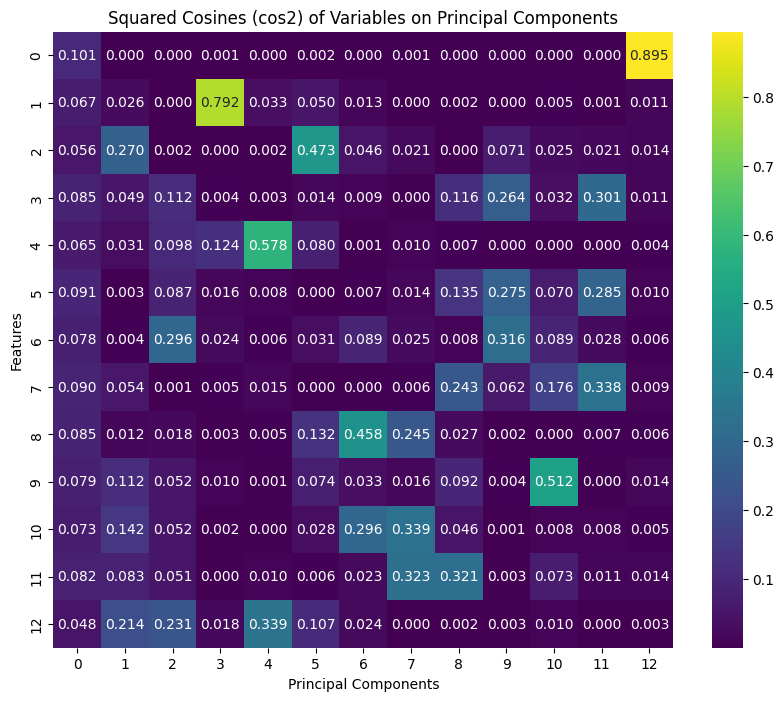

In [100]:
loadings = pca.components_.T  # Transpose to match variables as rows, components as columns
cos2 = loadings**2  # Square the loadings for cos2

# Visualize the squared cosines (cos2) with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cos2,fmt =".3f" ,annot=True, cmap="viridis", cbar=True)
plt.title("Squared Cosines (cos2) of Variables on Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Features")
plt.show()

## Source

1. https://blogs.worldbank.org/en/opendata/new-world-bank-country-classifications-income-level-2022-2023 
2. https://datahelpdesk.worldbank.org/knowledgebase/articles/77933-what-is-the-world-bank-atlas-method 
3. Shafik, N. (1994). Economic development and environmental quality: An econometric analysis. Oxford Economic Papers, 46(Supplement), 757-773. The World Bank.
4. https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/ 
5. https://theeffectbook.net/ch-FixedEffects.html?panelset=python-code&panelset1=python-code2 
6. https://ourworldindata.org/grapher/political-regime 
7. Carlsson, F., & Lundström, S. (2001). Political and Economic Freedom and the Environment: The Case of CO2 Emissions (Working Papers in Economics No. 29, 2nd version). Department of Economics, Göteborg University. 
8. https://vitalflux.com/pca-explained-variance-concept-python-example/